In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
%pip install -qU google-generativeai
%pip install -qU google-ai-generativelanguage==0.6.15
%pip install -qU langchain-google-genai
%pip install -qU langchain-community
%pip install -qU langgraph
%pip install -qU langgraph langchain-community
%pip install -qU python-dotenv

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated, List, Sequence, Union
import operator
import google.generativeai as genai
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, ToolMessage, BaseMessage
from langchain_community.tools.tavily_search import TavilySearchResults

In [4]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]

In [5]:
import os
from dotenv import load_dotenv

load_dotenv()

GEMINI_API_KEY = os.getenv('GEMINI_API_KEY')
TAVILY_API_KEY = os.getenv('TAVILY_API_KEY')

In [6]:
tool = TavilySearchResults(max_results=4)
print(type(tool))
print(tool.name)

<class 'langchain_community.tools.tavily_search.tool.TavilySearchResults'>
tavily_search_results_json


C:\Users\Usuario\AppData\Local\Temp\ipykernel_4200\1287549681.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tool = TavilySearchResults(max_results=4)


In [7]:
%pip install -qU langchain-tavily

Note: you may need to restart the kernel to use updated packages.


In [15]:
class Agent:
    def __init__(self, model, tools, system=""):
        self.system = system
        graph = StateGraph(AgentState)
        
        # Definición de los nodos
        graph.add_node("llm", self.call_gemini)
        graph.add_node("action", self.take_action)
        
        # Borde condicional desde el LLM
        graph.add_conditional_edges(
            "llm",
            self.exists_action,
            {True: "action", False: END}
        )
        
        # Transición de regreso de la acción al LLM
        graph.add_edge("action", "llm")
        
        # Entrada al grafo
        graph.set_entry_point("llm")
        
        self.graph = graph.compile()
        self.tools = {t.name: t for t in tools}
        self.model = model.bind_tools(tools)

    def exists_action(self, state: AgentState):
        # Verifica si el último mensaje del LLM contiene llamadas a herramientas
        result = state['messages'][-1]
        return len(result.tool_calls) > 0

    def call_gemini(self, state: AgentState):
        # Llama a Gemini pasando el historial de mensajes
        messages = state['messages']
        if self.system:
            messages = [SystemMessage(content=self.system)] + messages
        message = self.model.invoke(messages)
        return {'messages': [message]}

    def take_action(self, state: AgentState):
        # Ejecuta las herramientas solicitadas por el LLM
        tool_calls = state['messages'][-1].tool_calls
        results = []
        for t in tool_calls:
            print(f"Llamando a la herramienta: {t['name']}")
            if not t['name'] in self.tools:
                print("\n .... Nombre de herramienta incorrecto ....")
                result = "bad tool name, try again next time."
            else:
                result = self.tools[t['name']].invoke(t['args'])
            results.append(ToolMessage(tool_call_id=t['id'], name=t['name'], content=str(result)))
        print("Regresando la respuesta al modelo...")
        return {'messages': results}



In [16]:
prompt = """Eres un asistente de investigación inteligente. Utiliza el motor de búsqueda para buscar información. \
Tienes permiso para realizar múltiples consultas (ya sea de forma conjunta o secuencial). \
Busca información únicamente cuando tengas claro lo que deseas. \
Si necesitas investigar alguna información antes de hacer una pregunta de seguimiento, ¡tienes permiso para hacerlo!
"""

model = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite", temperature=0)

abot = Agent(model, [tool], system=prompt)

In [17]:
mermaid_code = abot.graph.get_graph().draw_mermaid()
print(mermaid_code)

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	llm(llm)
	action(action)
	__end__([<p>__end__</p>]):::last
	__start__ --> llm;
	action --> llm;
	llm -. &nbsp;False&nbsp; .-> __end__;
	llm -. &nbsp;True&nbsp; .-> action;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



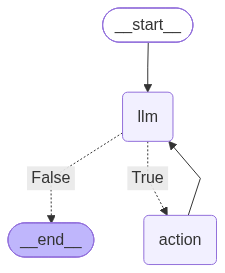

In [18]:
from IPython.display import Image, display

try:
    image_data = abot.graph.get_graph().draw_mermaid_png()
    display(Image(data=image_data))
except Exception as e:
    print(f"Error al tratar generar el PNG de Mermaid: {e}")
    print("\nVerifique que la versión de LangGraph posee el método `.draw_mermaid_png()`.")
    print("Como alternativa, use `.draw_mermaid()` para obtener la string y visualizarla externamente.")

In [19]:
tool_instance = TavilySearchResults(max_results=4)
abot = Agent(model, [tool_instance], system=prompt)

In [20]:
prompt = """Eres un asistente de investigación inteligente. Utiliza el motor de búsqueda para buscar información. \
Tienes permiso para realizar múltiples consultas (ya sea de forma conjunta o secuencial). \
Busca información únicamente cuando tengas claro lo que deseas. \
Si necesitas investigar alguna información antes de hacer una pregunta de seguimiento, ¡tienes permiso para hacerlo!
"""

model = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite", temperature=0)

abot = Agent(model, [tool_instance], system=prompt)

messages = [HumanMessage(content="Cómo está el clima en Pereira hoy?")]

print("Iniciando la interacción con el agente:")
final_result_state = None

for s in abot.graph.stream({"messages": messages}):
    print(s)
    print("---")
    final_result_state = s

print(f"\nResultado Final:")
if final_result_state and 'llm' in final_result_state and final_result_state['llm']['messages']:
    print(final_result_state['llm']['messages'][-1].content)
else:
    print("Ningún resultado final o resultado inesperado.")

Iniciando la interacción con el agente:
{'llm': {'messages': [AIMessage(content=[], additional_kwargs={'function_call': {'name': 'tavily_search_results_json', 'arguments': '{"query": "clima en Pereira hoy"}'}, '__gemini_function_call_thought_signatures__': {'call_2298790': 'EnEKbwERTTIPiHOena3cQ9Y0GFREIlxg5+p5VKkt1uZbkLLcl7Nq2hhtsrqOR2SsqYJrM3ZGEPsbmlg3LAX7Gu0UEjGbQW4OJUbkhA6znym+WnKsPEXGbdMHMqw4YLpDWplXL8D+daXglzPsk8QivyhTmA=='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a040c1-c329-7211-ac99-545ef6d6c52d-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'clima en Pereira hoy'}, 'id': 'call_2298790', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 159, 'output_tokens': 26, 'total_tokens': 185, 'input_token_details': {'cache_read': 0}})]}}
---
Llamando a la herramienta: tavily_search_results_json
Regresando la respuesta al

In [24]:
from datetime import date
current_date = date.today().strftime("%d/%m/%Y") # Formato dd/mm/aaaa

prompt = f"""
Eres un asistente de investigación inteligente y altamente actualizado. \
Tu principal prioridad es encontrar la información más RECIENTE y EN TIEMPO REAL siempre que sea posible. \
La fecha actual es {{current_date}}. \
Al buscar sobre el clima o eventos que se refieran a "hoy" o "ahora", \
DEBES **incluir la fecha actual `{current_date}` en tu consulta para la herramienta de búsqueda**. \
Por ejemplo, si la pregunta es "clima en ciudad x hoy", la consulta para la herramienta debe ser "clima en ciudad x {current_date}". \
Ignora o descarta información que claramente se refiera a fechas pasadas o futuras al responder preguntas sobre "hoy". \
Utiliza el motor de búsqueda para buscar información, procurando siempre el "hoy" o el "ahora" cuando el contexto lo indique. \
Tienes permiso para realizar múltiples llamadas (ya sea en conjunto o en secuencia). \
Busca información solo cuando tengas claro lo que deseas. \
Si necesitas investigar alguna información antes de hacer una pregunta de seguimiento, ¡tienes permiso para hacerlo!
"""

model_instance = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite", temperature=0)
tool_instance = TavilySearchResults(max_results=4)
abot = Agent(model_instance, [tool_instance], system=prompt)

user_query = "cómo está el clima en Pereira hoy?"

messages = [HumanMessage(content=user_query)]

print("Iniciando la interacción con el agente:")
final_result_state = None
for s in abot.graph.stream({"messages": messages}):
    print(s)
    print("---")
    final_result_state = s

Iniciando la interacción con el agente:
{'llm': {'messages': [AIMessage(content=[], additional_kwargs={'function_call': {'name': 'tavily_search_results_json', 'arguments': '{"query": "clima en Pereira 26/08/2026"}'}, '__gemini_function_call_thought_signatures__': {'call_2068658': 'EnEKbwERTTIPN2l4f623cJ71kfB3KXp8OvUo81OZ65LLb3rhaDPnhkibzbrt1Qrw2Ku99Sd2gW2nRtjm6x8+K7LFNLXhAp/Z94SbN+TuuuabnzQaxlPbvdNrtlFtsdifs7OmKQWNrgFue5g/q5oVrOTnuQ=='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a040c8-d7e0-7a62-aea5-375975c09f1e-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'clima en Pereira 26/08/2026'}, 'id': 'call_2068658', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 324, 'output_tokens': 36, 'total_tokens': 360, 'input_token_details': {'cache_read': 0}})]}}
---
Llamando a la herramienta: tavily_search_results_json
Regresando l

In [25]:
user_query_tomorrow = "Cómo estará el clima de Pereira mañana?" #actualizamos solamente la pregunta del usuario

messages_tomorrow = [HumanMessage(content=user_query_tomorrow)]

print("\n--- Iniciando la interacción con el agente para mañana---")
final_result_state_tomorrow = None
for s in abot.graph.stream({"messages": messages_tomorrow}):
    print(s)
    print("---")
    final_result_state_tomorrow = s

print("\n--- Resultado Final para mañana ---")
if final_result_state_tomorrow and 'llm' in final_result_state_tomorrow and final_result_state_tomorrow['llm']['messages']:
    print(final_result_state_tomorrow['llm']['messages'][-1].content)
else:
    print("Ningún resultado final o resultado inesperado para mañana.")


--- Iniciando la interacción con el agente para mañana---
{'llm': {'messages': [AIMessage(content=[], additional_kwargs={'function_call': {'name': 'tavily_search_results_json', 'arguments': '{"query": "clima en Pereira 27/08/2026"}'}, '__gemini_function_call_thought_signatures__': {'call_2595972': 'EnEKbwERTTIPKuM0QkQQ+734zjcb+EiWo2qcLcrgAKinbhB/w5EvdV8hvbmUkDIqjXwJKCPgdysOCZyPClhla9hxsgAGPzzeIGzjM5kGtO1mC2vaHNlYFg9F/Ub136T9Pf6OA31ADaiuJKUNhVbxpqqRcg=='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a040c9-872e-7862-ab4f-c491ba983cde-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'clima en Pereira 27/08/2026'}, 'id': 'call_2595972', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 324, 'output_tokens': 36, 'total_tokens': 360, 'input_token_details': {'cache_read': 0}})]}}
---
Llamando a la herramienta: tavily_search_result

In [26]:
user_query_yesterday = "Cómo fue el clima de Pereira ayer?"

messages_yesterday = [HumanMessage(content=user_query_yesterday)]

print("\n--- Iniciando la interacción con el agente---")
final_result_state_yesterday = None
for s in abot.graph.stream({"messages": messages_yesterday}):
    print(s)
    print("---")
    final_result_state_yesterday = s
    
print("\n--- Resultado Final ---")
if final_result_state_yesterday and 'llm' in final_result_state_yesterday and final_result_state_yesterday['llm']['messages'][-1]:
    print(final_result_state_yesterday['llm']['messages'][-1].content)
else:
    print("Ningún resultado final o resultado inesperado.")


--- Iniciando la interacción con el agente---
{'llm': {'messages': [AIMessage(content=[], additional_kwargs={'function_call': {'name': 'tavily_search_results_json', 'arguments': '{"query": "clima en Pereira ayer 25/08/2026"}'}, '__gemini_function_call_thought_signatures__': {'call_2470065': 'EnEKbwERTTIPcp0+4aKnaltP5YGuj3J4Nc5BcxJSvbRKjlh3AyHmEM8G3axp2JoAPD37PgA9Kgqb87v7A3A04fMMYDldNhU8qhmjlT3AbtUUVmJa0E2k9cU1LODbzxqVdtyGiK1lcrM5MPHKtQ1JrTIf3g=='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a040ca-a1c4-73d2-aff5-91cd28fe05ff-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'clima en Pereira ayer 25/08/2026'}, 'id': 'call_2470065', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 324, 'output_tokens': 37, 'total_tokens': 361, 'input_token_details': {'cache_read': 0}})]}}
---
Llamando a la herramienta: tavily_search_results_

In [44]:
class Agent:
    def __init__(self, model, tools, system=""):
        self.system = system
        graph = StateGraph(AgentState)
        
        # Definición de nodos
        graph.add_node("llm", self.call_gemini)
        graph.add_node("action", self.take_action)
        
        # Bordes condicionales
        graph.add_conditional_edges(
            "llm",
            self.exists_action,
            {True: "action", False: END}
        )
        
        # Transición de regreso de la acción al LLM
        graph.add_edge("action", "llm")
        graph.set_entry_point("llm")
        
        self.graph = graph.compile()
        self.tools = {t.name: t for t in tools}
        self.model = model.bind_tools(tools)

    def exists_action(self, state: AgentState):
        result = state['messages'][-1]
        return len(result.tool_calls) > 0

    def call_gemini(self, state: AgentState):
        messages = state['messages']
        if self.system:
            messages = [SystemMessage(content=self.system)] + messages
        message = self.model.invoke(messages)
        return {'messages': [message]}

    def take_action(self, state: AgentState):
        tool_calls = state['messages'][-1].tool_calls
        results = []
        for t in tool_calls:
            # Imprime exactamente el formato de tu imagen:
            print(f"Calling: {t}")
            
            if not t['name'] in self.tools:
                print("\n .... Nombre de herramienta incorrecto ....")
                result = "bad tool name, try again next time."
            else:
                result = self.tools[t['name']].invoke(t['args'])
            results.append(ToolMessage(tool_call_id=t['id'], name=t['name'], content=str(result)))
        print("Regresando la respuesta al modelo...")
        return {'messages': results}



In [46]:
abot = Agent(model, [tool], 
system=prompt)


In [47]:
messages = [HumanMessage(content="Cómo está el clima en Pereyra hoy?")]
result = abot.graph.invoke({"messages": messages})

Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'clima en Pereyra 26/08/2026'}, 'id': 'call_1874006', 'type': 'tool_call'}
Regresando la respuesta al modelo...


In [48]:
result['messages'][-1].content

[{'type': 'text',
  'text': 'Para hoy, 26 de agosto de 2026, el clima en **Pereyra** (provincia de Buenos Aires, Argentina) presenta las siguientes condiciones:\n\n*   **Estado del tiempo:** Se espera lluvia débil con cielo parcialmente nuboso.\n*   **Temperaturas:** Una máxima de 18°C y una mínima de 8°C.\n*   **Viento:** Moderado, proveniente del noreste, con velocidades entre 15 y 34 km/h.\n*   **Precipitaciones:** Hay una probabilidad del 70% de lluvia, con una estimación de 1.6 mm.\n\n*(Nota: Si te referías a la ciudad de **Pereira** en Colombia, el clima hoy es lluvioso, con una temperatura máxima de 24°C y una mínima de 14°C, y una probabilidad de lluvia del 100%).*',
  'extras': {'signature': 'EnEKbwERTTIPrOFOmuhgPFi5ruQCKUYI41VqPHHqELsVozkb3FViC84sRF5HYfixO0EacybqOESNgLQZlsc0kRhotXjtviF27szsOo3jol93KCmkeqyjCCNpLM1VcgglL1W7zDUsbzaE5o15NgwDBdilEg=='}}]

In [49]:
messages = [HumanMessage(content="Cómo está el clima en Pereyra y en Medellín hoy?")]
result = abot.graph.invoke({"messages": messages})

Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'clima en Pereyra 26/08/2026'}, 'id': 'call_2519188', 'type': 'tool_call'}
Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'clima en Medellín 26/08/2026'}, 'id': 'call_2519189', 'type': 'tool_call'}
Regresando la respuesta al modelo...


In [51]:
result['messages'][-1].content

[{'type': 'text',
  'text': 'Para hoy, **26 de agosto de 2026**, el pronóstico del clima en estas ciudades es el siguiente:\n\n### **Medellín, Colombia**\nLa jornada en Medellín está marcada por condiciones inestables:\n*   **Estado del tiempo:** Se esperan lluvias intermitentes durante el día, con cielos mayormente nublados.\n*   **Temperaturas:** Se prevé una temperatura máxima que oscila entre los **25°C y 27°C**, con una mínima cercana a los **16°C**.\n*   **Precipitaciones:** Existe una probabilidad alta de lluvias (alrededor del 74%) especialmente durante la tarde y la noche. Se recomienda llevar paraguas.\n*   **Condiciones generales:** Humedad elevada y vientos leves.\n\n### **Pereira, Colombia**\nEn Pereira, el panorama es de alta probabilidad de precipitaciones:\n*   **Estado del tiempo:** Se reporta lluvia moderada a ligera durante la jornada.\n*   **Temperaturas:** Se espera una temperatura máxima de **24°C** y una mínima de **14°C**.\n*   **Precipitaciones:** La probabilid